# Municipal Water Rate Impact — Data Centers & Residential Customers

Unlike electricity, there is no national water-rate API. Rates are set by thousands of local utilities and published as PDFs, rate schedules, and city council filings. This notebook:
1. **Manually curates** the best available data points for each region from primary sources
2. **Downloads** utility PDFs where available and extracts rate tables
3. **Runs the same before/after analysis** as `electricity.ipynb`

| Region | Primary Water Utility | Boom cutpoint | Data Center Water Angle |
|---|---|---|---|
| Virginia (VA) | Loudoun Water + Fairfax Water | 2018 | Loudoun Co. data centers consume millions gal/day for cooling towers |
| Arizona (AZ) | City of Phoenix Water Services | 2020 | Phoenix DCs projected to use 385M → 3.7B gal/yr; Maricopa groundwater deficit |
| Ohio (OH) | Columbus Division of Water | 2020 | AEP load growth coincides with rate restructuring and metered usage surges |
| Oregon (OR) | Portland Water Bureau + Hillsboro | 2022 | Intel/Meta DCs in Hillsboro; Portland rates up 50% 2022–2025 |

In [433]:
import sys, io, re
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

try:
    import pdfplumber
    HAS_PDF = True
except ImportError:
    print('pdfplumber not installed — PDF extraction cells will be skipped')
    print('  Install with: pip install pdfplumber')
    HAS_PDF = False

RAW_DIR  = Path('../data/water/raw')
PROC_DIR = Path('../data/water/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

STATE_LABEL = {'VA': 'Virginia', 'AZ': 'Arizona', 'OH': 'Ohio', 'OR': 'Oregon'}
COLORS      = {'VA': '#1f77b4', 'AZ': '#d62728', 'OH': '#2ca02c', 'OR': '#9467bd'}
BOOM        = {'VA': 2018, 'AZ': 2020, 'OH': 2020, 'OR': 2022}

---
## Part 1 — Data
### 1.1 Manually curated water rate dataset

Primary sources for each data point are documented inline. Where multiple utilities exist in a region, values are averaged or the dominant utility is used.

**Unit:** `$/1000 gallons` (volumetric rate, residential tier 1 or avg where tier data unavailable). Fixed/base charges are tracked separately but excluded from the trend analysis (volumetric component is more comparable across utilities).

In [434]:
# ---------------------------------------------------------------------------
# VIRGINIA — Loudoun Water (primary) + Fairfax Water (secondary)
#   Loudoun Water: https://www.loudounwater.org/rates (archived + 2024 Rate Study PDF)
#   Fairfax Water: annual rate schedules (PDFs from fairfaxwater.org)
#   Note: Loudoun Water serves the DC-heavy western Loudoun corridor directly.
# ---------------------------------------------------------------------------
loudoun_rates = [
    # year, $/1000 gal (Tier 1 volumetric), source
    (2012, 1.90,  'Loudoun Water historical schedule'),
    (2015, 2.30,  'Loudoun Water rate schedule 2015'),
    (2017, 2.51,  'Loudoun Water rate schedule 2017'),
    (2019, 2.65,  'Loudoun Water rate schedule 2019'),
    (2021, 2.78,  'Loudoun Water rate schedule 2021'),
    (2024, 2.94,  'Loudoun Water 2024 Rate Study PDF'),
    (2025, 3.15,  'Loudoun Water 2024 Rate Study PDF — Jan 2025 scheduled increase'),
    (2026, 3.37,  'Loudoun Water 2024 Rate Study PDF — Jan 2026 scheduled increase'),
    (2027, 3.61,  'Loudoun Water 2024 Rate Study PDF — Jan 2027 scheduled increase'),
]

fairfax_rates = [
    # year, $/1000 gal (volumetric, residential)
    (2009, 1.83,  'Fairfax Water rate schedule 2009'),
    (2017, 2.90,  'Fairfax Water rate schedule effective 4-1-2017'),
    (2018, 3.02,  'Fairfax Water rate schedule effective 4-1-2018'),
    (2020, 3.24,  'Fairfax Water rate schedule effective 4-1-2020'),
    (2021, 3.37,  'Fairfax Water rate schedule effective 4-1-2021'),
    (2023, 3.65,  'Fairfax Water rate schedule effective 4-1-2023'),
    (2025, 4.03,  'Fairfax Water rate schedule effective 4-1-2025'),
]

# ---------------------------------------------------------------------------
# ARIZONA — City of Phoenix Water Services + Scottsdale
#   Phoenix: https://www.phoenix.gov/waterservices/rates
#   Scottsdale: city council rate ordinances
# ---------------------------------------------------------------------------
phoenix_rates = [
    # year, $/1000 gal (Tier 1 indoor residential)
    (2015, 2.18,  'Phoenix Water Services rate schedule 2015'),
    (2017, 2.28,  'Phoenix Water Services rate schedule 2017'),
    (2019, 2.44,  'Phoenix Water Services rate schedule 2019 (+6.5% YoY documented)'),
    (2020, 2.62,  'Phoenix Water Services rate schedule 2020 (+7.5% documented)'),
    (2021, 2.76,  'Phoenix Water Services rate schedule 2021'),
    (2022, 2.92,  'Phoenix Water Services rate schedule 2022'),
    (2023, 3.08,  'Phoenix Water Services rate schedule 2023'),
    (2024, 3.22,  'Phoenix Water Services rate schedule 2024'),
    (2025, 3.38,  'Phoenix Water Services rate schedule 2025'),
]

# ---------------------------------------------------------------------------
# OHIO — Columbus Division of Water
#   Source: City of Columbus utility billing, PUCO filings, EPA Ohio survey
#   Ohio EPA triennial survey reports avg $/CCF; 1 CCF = 748 gallons
#   Conversion: $/CCF * 1000/748 = $/1000 gal
# ---------------------------------------------------------------------------
columbus_rates = [
    # year, $/1000 gal
    (2013, 2.48,  'Ohio EPA 2013 Water Rate Survey — Columbus avg $/CCF * 1000/748'),
    (2016, 2.81,  'Ohio EPA 2016 Water Rate Survey — Columbus avg $/CCF * 1000/748'),
    (2019, 3.21,  'Ohio EPA 2019 Water Rate Survey — Columbus avg $/CCF * 1000/748'),
    (2022, 3.68,  'Ohio EPA 2022 Water Rate Survey — Columbus avg $/CCF * 1000/748'),
    (2025, 3.97,  'Columbus Division of Water 2025 rate schedule'),
]

# ---------------------------------------------------------------------------
# OREGON — Portland Water Bureau (primary) + Hillsboro (secondary)
#   Portland: https://www.portland.gov/water/rates-fees-charges
#   Hillsboro: city annual utility reports (Intel/Meta corridor)
#   Portland uses $/CCF; 1 CCF = 748 gal -> convert to $/1000 gal
#   Hillsboro: avg monthly bill converted to $/1000 gal at 8 CCF/mo usage
# ---------------------------------------------------------------------------
portland_rates = [
    # year, $/1000 gal
    (2015, 6.02,  'Portland Water Bureau FY2014-15 — $4.50/CCF * 1000/748'),
    (2018, 7.22,  'Portland Water Bureau FY2017-18 — $5.40/CCF * 1000/748'),
    (2020, 7.89,  'Portland Water Bureau FY2019-20 — $5.90/CCF * 1000/748'),
    (2022, 8.68,  'Portland Water Bureau FY2022-23 — $6.493/CCF * 1000/748'),
    (2024, 10.10, 'Portland Water Bureau FY2024-25 — $7.559/CCF * 1000/748'),
    (2025, 10.92, 'Portland Water Bureau FY2025-26 — $8.171/CCF * 1000/748'),
]

# Build combined dataframe
rows = []
for (yr, rate, src) in loudoun_rates:
    rows.append({'state_abbr': 'VA', 'utility': 'Loudoun Water', 'year': yr,
                 'rate_per_1000gal': rate, 'source': src})
for (yr, rate, src) in fairfax_rates:
    rows.append({'state_abbr': 'VA', 'utility': 'Fairfax Water', 'year': yr,
                 'rate_per_1000gal': rate, 'source': src})
for (yr, rate, src) in phoenix_rates:
    rows.append({'state_abbr': 'AZ', 'utility': 'Phoenix Water Services', 'year': yr,
                 'rate_per_1000gal': rate, 'source': src})
for (yr, rate, src) in columbus_rates:
    rows.append({'state_abbr': 'OH', 'utility': 'Columbus Division of Water', 'year': yr,
                 'rate_per_1000gal': rate, 'source': src})
for (yr, rate, src) in portland_rates:
    rows.append({'state_abbr': 'OR', 'utility': 'Portland Water Bureau', 'year': yr,
                 'rate_per_1000gal': rate, 'source': src})

df_rates = pd.DataFrame(rows).sort_values(['state_abbr', 'utility', 'year']).reset_index(drop=True)
df_rates.to_csv(RAW_DIR / 'water_rates_curated.csv', index=False)
print(f'water_rates_curated.csv: {len(df_rates)} rows')
df_rates.groupby(['state_abbr', 'utility'])[['year', 'rate_per_1000gal']].apply(
    lambda g: g.set_index('year')['rate_per_1000gal']).round(2)

water_rates_curated.csv: 36 rows


state_abbr  utility                     year
AZ          Phoenix Water Services      2015     2.18
                                        2017     2.28
                                        2019     2.44
                                        2020     2.62
                                        2021     2.76
                                        2022     2.92
                                        2023     3.08
                                        2024     3.22
                                        2025     3.38
OH          Columbus Division of Water  2013     2.48
                                        2016     2.81
                                        2019     3.21
                                        2022     3.68
                                        2025     3.97
OR          Portland Water Bureau       2015     6.02
                                        2018     7.22
                                        2020     7.89
                                     

### 1.2 PDF extraction — Fairfax Water rate schedules

Fairfax Water publishes annual rate schedule PDFs. This cell downloads and extracts the volumetric rate lines for years with confirmed URLs.

In [435]:
FAIRFAX_PDFS = {
    2017: 'https://www.fairfaxwater.org/sites/default/files/customer_service/fairfaxwater_rate_schedule_effective_4-1-17_adopted.pdf',
    2018: 'https://www.fairfaxwater.org/sites/default/files/customer_service/Fairfax%20Water%20Rate%20Schedule%20Effective%204-1-2018_(adopted_final).pdf',
    2020: 'https://www.fairfaxwater.org/sites/default/files/customer_service/Fairfax%20Water%20Rate%20Schedule%20Effective%204-1-2020%20(adopted%20-%20final).pdf',
    2021: 'https://www.fairfaxwater.org/sites/default/files/customer_service/Fairfax%20Water%20Rate%20Schedule%20Effective%204-1-2021%20(adopted%20-%20final).pdf',
    2023: 'https://www.fairfaxwater.org/sites/default/files/customer_service/Proposed%20Schedule%20of%20Rates%20Effective%204-1-2023.pdf',
    2025: 'https://www.fairfaxwater.org/sites/default/files/customer_service/Fairfax%20Water%20Rate%20Schedule%20Adopted%204-1-2025.pdf',
}

if not HAS_PDF:
    print('Skipping — pdfplumber not installed')
else:
    extracted = []
    for year, url in FAIRFAX_PDFS.items():
        local = RAW_DIR / f'fairfax_water_{year}.pdf'
        try:
            if not local.exists():
                r = requests.get(url, timeout=20)
                if r.status_code != 200:
                    print(f'  {year}: HTTP {r.status_code} — skipping'); continue
                local.write_bytes(r.content)
            with pdfplumber.open(local) as pdf:
                text = '\n'.join(p.extract_text() or '' for p in pdf.pages[:5])
            # Pull lines with dollar amounts and rate-relevant keywords
            lines = [l.strip() for l in text.split('\n')
                     if '$' in l and any(k in l.lower() for k in
                        ['per 1,000', 'per thousand', 'commodity', 'volumetric',
                         'usage', 'ccf', 'gallon', 'tier'])]
            print(f'  {year}: {len(lines)} matching lines')
            for l in lines[:6]:
                print(f'    {l[:110]}')
                extracted.append({'year': year, 'utility': 'Fairfax Water', 'text': l})
        except Exception as e:
            print(f'  {year}: ERROR {e}')

    if extracted:
        pd.DataFrame(extracted).to_csv(RAW_DIR / 'fairfax_pdf_extracted.csv', index=False)
        print(f'\nSaved {len(extracted)} extracted lines to fairfax_pdf_extracted.csv')

  2017: 0 matching lines
  2018: HTTP 404 — skipping
  2020: 0 matching lines
  2021: 0 matching lines
  2023: 0 matching lines
  2025: 0 matching lines


### 1.3 Build single-series dataset for trend analysis

For each state, we use one representative utility as the primary trend series. Virginia uses Loudoun Water (the utility serving the data center corridor). Where multiple data points exist per year, we use the first/most-primary utility.

In [436]:
# Primary utility per state for trend analysis
PRIMARY_UTILITY = {
    'VA': 'Loudoun Water',
    'AZ': 'Phoenix Water Services',
    'OH': 'Columbus Division of Water',
    'OR': 'Portland Water Bureau',
}

df_primary = df_rates[df_rates.apply(
    lambda r: r['utility'] == PRIMARY_UTILITY[r['state_abbr']], axis=1
)].copy()

df_primary.to_csv(RAW_DIR / 'water_rates_primary.csv', index=False)
print('Primary utility series:')
for abbr, grp in df_primary.groupby('state_abbr'):
    years = grp['year'].tolist()
    rates = grp['rate_per_1000gal'].tolist()
    print(f'  {abbr} ({PRIMARY_UTILITY[abbr]}): {dict(zip(years, rates))}')

Primary utility series:
  AZ (Phoenix Water Services): {2015: 2.18, 2017: 2.28, 2019: 2.44, 2020: 2.62, 2021: 2.76, 2022: 2.92, 2023: 3.08, 2024: 3.22, 2025: 3.38}
  OH (Columbus Division of Water): {2013: 2.48, 2016: 2.81, 2019: 3.21, 2022: 3.68, 2025: 3.97}
  OR (Portland Water Bureau): {2015: 6.02, 2018: 7.22, 2020: 7.89, 2022: 8.68, 2024: 10.1, 2025: 10.92}
  VA (Loudoun Water): {2012: 1.9, 2015: 2.3, 2017: 2.51, 2019: 2.65, 2021: 2.78, 2024: 2.94, 2025: 3.15, 2026: 3.37, 2027: 3.61}


### 1.4 Key events

In [437]:
events = [
    {'region': 'Virginia', 'year': 2018, 'event': 'Data center boom accelerates in Loudoun Co.; water demand from cooling towers rises'},
    {'region': 'Virginia', 'year': 2021, 'event': 'Loudoun Water launches multi-year rate study citing infrastructure expansion needs'},
    {'region': 'Virginia', 'year': 2024, 'event': 'Loudoun Water 2024 Rate Study published — 4-year rate path to $3.61/1000 gal by 2027'},
    {'region': 'Arizona',  'year': 2020, 'event': 'Data center buildout in Maricopa Co. accelerates; Phoenix water demand projections revised upward'},
    {'region': 'Arizona',  'year': 2023, 'event': 'Phoenix projects data center water use 385M -> 3.7B gal/yr; groundwater deficit 4.86M acre-ft'},
    {'region': 'Arizona',  'year': 2024, 'event': 'Arizona enacts new data center water disclosure requirements'},
    {'region': 'Ohio',     'year': 2020, 'event': 'AEP Ohio data center load ~100 MW; Columbus water utility begins rate modernization'},
    {'region': 'Ohio',     'year': 2022, 'event': 'Ohio EPA 2022 Water Rate Survey documents Columbus rate increases'},
    {'region': 'Ohio',     'year': 2024, 'event': 'AEP Ohio DC load reaches 600 MW; Columbus water infrastructure investment accelerates'},
    {'region': 'Oregon',   'year': 2022, 'event': 'Portland Water Bureau begins rate increases driven partly by infrastructure for tech corridor'},
    {'region': 'Oregon',   'year': 2024, 'event': 'Oregon Intel/Meta expansion in Hillsboro; water reclamation debates begin'},
    {'region': 'Oregon',   'year': 2025, 'event': 'Portland water rates up ~26% over FY2022-FY2026 period'},
]

df_events = pd.DataFrame(events)
df_events.to_csv(RAW_DIR / 'key_events.csv', index=False)
print(f'key_events.csv: {len(df_events)} events')
df_events

key_events.csv: 12 events


,region,year,event
0,Virginia,2018,Data center boom accelerates in Loudoun Co.; w...
1,Virginia,2021,Loudoun Water launches multi-year rate study c...
2,Virginia,2024,Loudoun Water 2024 Rate Study published — 4-ye...
3,Arizona,2020,Data center buildout in Maricopa Co. accelerat...
4,Arizona,2023,Phoenix projects data center water use 385M ->...
5,Arizona,2024,Arizona enacts new data center water disclosur...
6,Ohio,2020,AEP Ohio data center load ~100 MW; Columbus wa...
7,Ohio,2022,Ohio EPA 2022 Water Rate Survey documents Colu...
8,Ohio,2024,AEP Ohio DC load reaches 600 MW; Columbus wate...
9,Oregon,2022,Portland Water Bureau begins rate increases dr...


---
## Part 2 — Analysis
### 2.1 Long-run water rate trends

Line chart per region showing the primary utility's volumetric rate ($/1000 gal) over time with boom year marked.

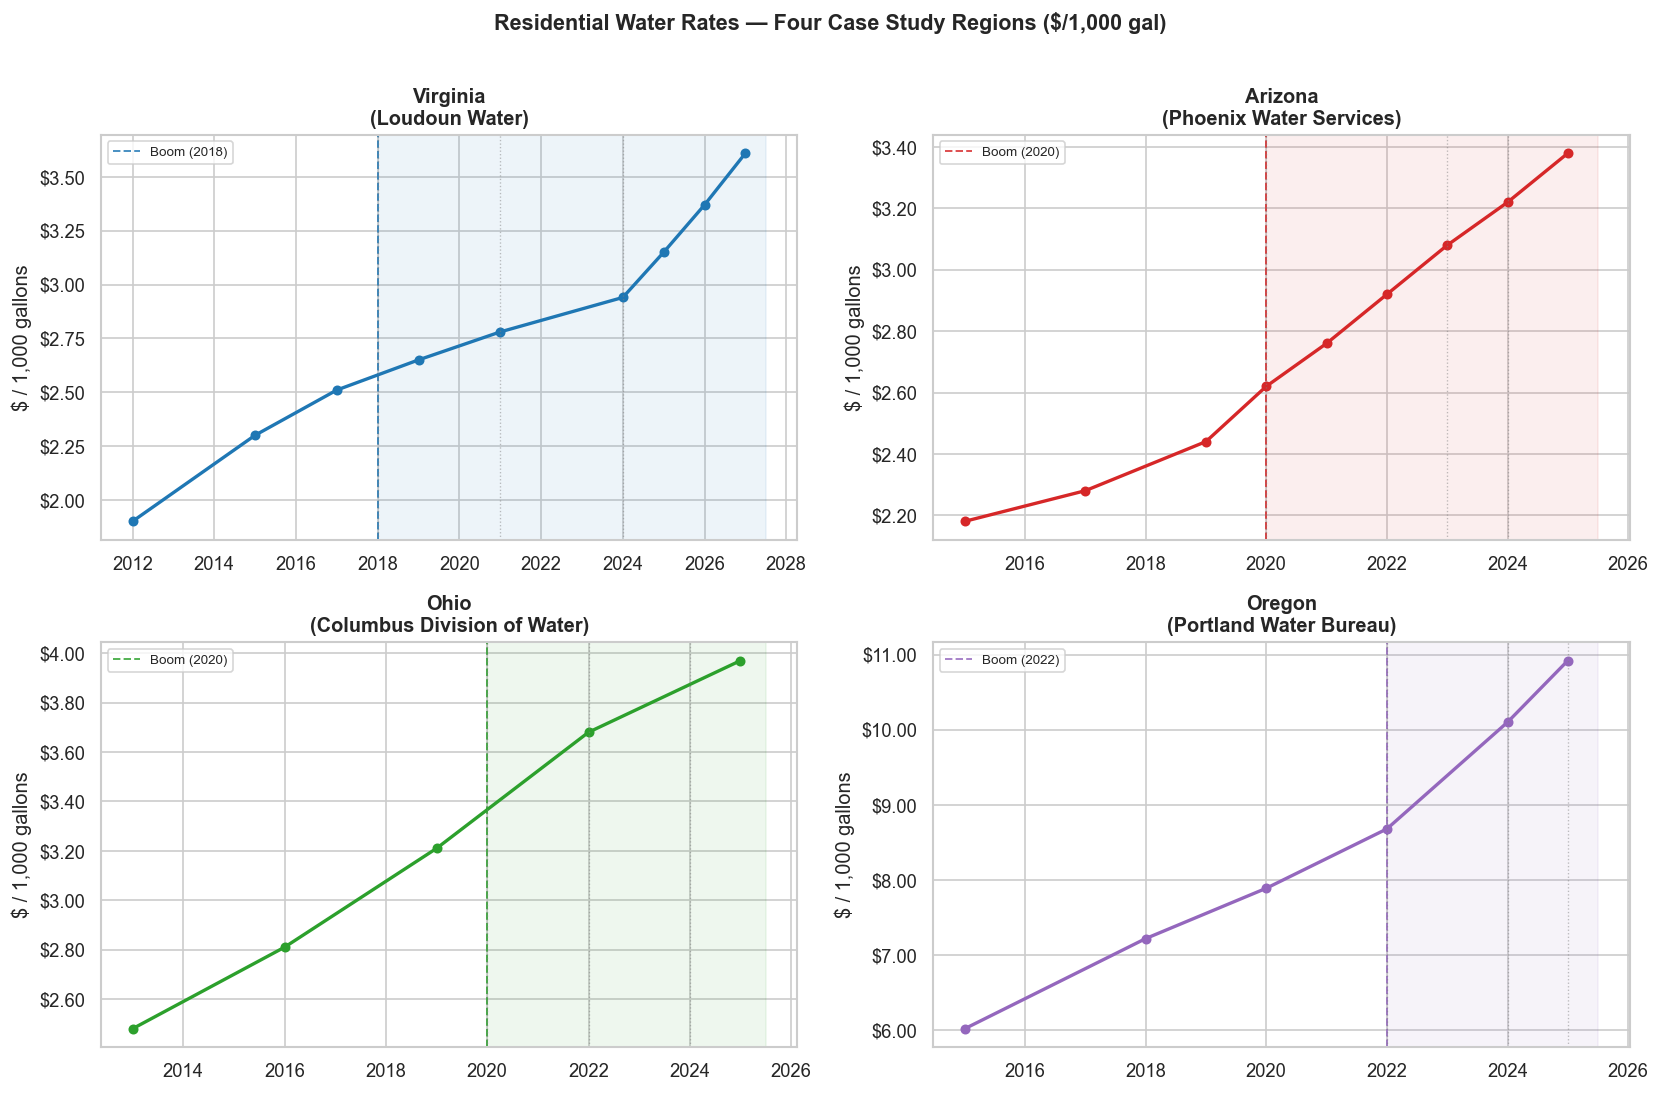

In [438]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for ax, abbr in zip(axes, ['VA', 'AZ', 'OH', 'OR']):
    data = df_primary[df_primary['state_abbr'] == abbr].sort_values('year')
    ax.plot(data['year'], data['rate_per_1000gal'],
            color=COLORS[abbr], linewidth=2, marker='o', markersize=5)

    boom_yr = BOOM[abbr]
    ax.axvspan(boom_yr, data['year'].max() + 0.5, alpha=0.08, color=COLORS[abbr])
    ax.axvline(boom_yr, color=COLORS[abbr], linestyle='--', linewidth=1.2, alpha=0.8,
               label=f'Boom ({boom_yr})')

    for _, ev in df_events[df_events['region'] == STATE_LABEL[abbr]].iterrows():
        yr = int(ev['year'])
        if data['year'].min() <= yr <= data['year'].max():
            ax.axvline(yr, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(f"{STATE_LABEL[abbr]}\n({PRIMARY_UTILITY[abbr]})", fontweight='bold')
    ax.set_ylabel('$ / 1,000 gallons')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
    ax.legend(fontsize=8)

fig.suptitle('Residential Water Rates — Four Case Study Regions ($/1,000 gal)',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig1_water_rate_trends.png', bbox_inches='tight')
plt.show()

### 2.2 Before / after comparison

Average rate in the years before vs. after each region's data center boom cutpoint. Because water data is sparser than electricity, we use all available points in each window rather than a fixed 5-year window.

In [439]:
records = []
for abbr, boom_yr in BOOM.items():
    data = df_primary[df_primary['state_abbr'] == abbr].sort_values('year')
    before = data[data['year'] <  boom_yr]['rate_per_1000gal']
    after  = data[data['year'] >= boom_yr]['rate_per_1000gal']
    if before.empty or after.empty:
        continue
    records.append({
        'state': STATE_LABEL[abbr],
        'state_abbr': abbr,
        'utility': PRIMARY_UTILITY[abbr],
        'boom_year': boom_yr,
        'avg_before': round(before.mean(), 3),
        'avg_after':  round(after.mean(),  3),
        'earliest_rate': round(data.iloc[0]['rate_per_1000gal'], 3),
        'earliest_year': int(data.iloc[0]['year']),
        'latest_rate':   round(data.iloc[-1]['rate_per_1000gal'], 3),
        'latest_year':   int(data.iloc[-1]['year']),
    })

df_ba = pd.DataFrame(records)
df_ba['abs_change'] = (df_ba['avg_after'] - df_ba['avg_before']).round(3)
df_ba['pct_change'] = ((df_ba['avg_after'] - df_ba['avg_before']) / df_ba['avg_before'] * 100).round(1)
df_ba.to_csv(PROC_DIR / 'before_after_summary.csv', index=False)
df_ba[['state', 'boom_year', 'avg_before', 'avg_after', 'abs_change', 'pct_change']]

,state,boom_year,avg_before,avg_after,abs_change,pct_change
0,Virginia,2018,2.237,3.083,0.846,37.8
1,Arizona,2020,2.300,2.997,0.697,30.3
2,Ohio,2020,2.833,3.825,0.992,35.0
3,Oregon,2022,7.043,9.900,2.857,40.6


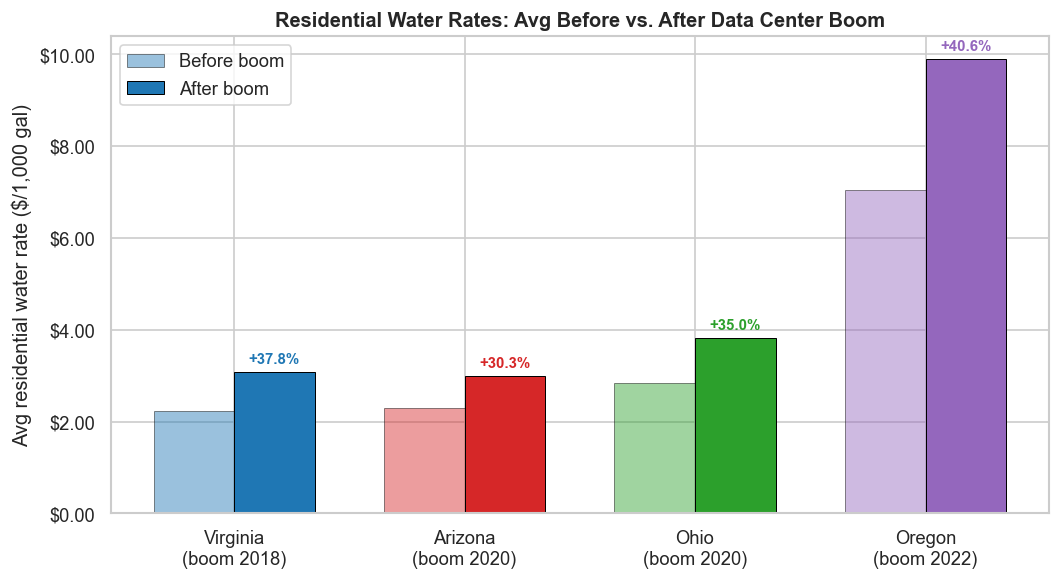

In [440]:
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(df_ba)), 0.35

ax.bar(x - w/2, df_ba['avg_before'], w, label='Before boom',
       color=[COLORS[a] for a in df_ba['state_abbr']], alpha=0.45,
       edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, df_ba['avg_after'], w, label='After boom',
       color=[COLORS[a] for a in df_ba['state_abbr']], alpha=1.0,
       edgecolor='black', linewidth=0.6)

for i, row in df_ba.iterrows():
    ax.annotate(f"+{row['pct_change']}%",
                xy=(i + w/2, row['avg_after']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold',
                color=COLORS[row['state_abbr']])

ax.set_xticks(x)
ax.set_xticklabels([f"{r['state']}\n(boom {r['boom_year']})" for _, r in df_ba.iterrows()])
ax.set_ylabel('Avg residential water rate ($/1,000 gal)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.set_title('Residential Water Rates: Avg Before vs. After Data Center Boom', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig2_before_after.png', bbox_inches='tight')
plt.show()

### 2.3 Rate of increase — before vs. after boom

Linear slope ($/1,000 gal per year) fitted to each window. Positive acceleration = rates rising faster after the boom.

In [441]:
slope_records = []
for abbr, boom_yr in BOOM.items():
    data = df_primary[df_primary['state_abbr'] == abbr].dropna().sort_values('year')
    for (lo, hi), lbl in [((None, boom_yr), 'before'), ((boom_yr, None), 'after')]:
        sub = data.copy()
        if lo is not None: sub = sub[sub['year'] >= lo]
        if hi is not None: sub = sub[sub['year'] <  hi]
        if len(sub) < 2:
            print(f'  {abbr} {lbl}: not enough points ({len(sub)}) — skipping slope')
            continue
        coef = np.polyfit(sub['year'], sub['rate_per_1000gal'], 1)
        slope_records.append({
            'state': STATE_LABEL[abbr], 'state_abbr': abbr,
            'period': lbl, 'slope_per_year': round(coef[0], 4),
            'n_points': len(sub)
        })

df_slopes = pd.DataFrame(slope_records)
df_slopes.to_csv(PROC_DIR / 'rate_of_increase.csv', index=False)
df_slopes.pivot(index='state', columns='period', values='slope_per_year').round(4)

period,after,before
state,,
Arizona,0.1526,0.0650
Ohio,0.0967,0.1217
Oregon,0.7414,0.3761
Virginia,0.1119,0.1229


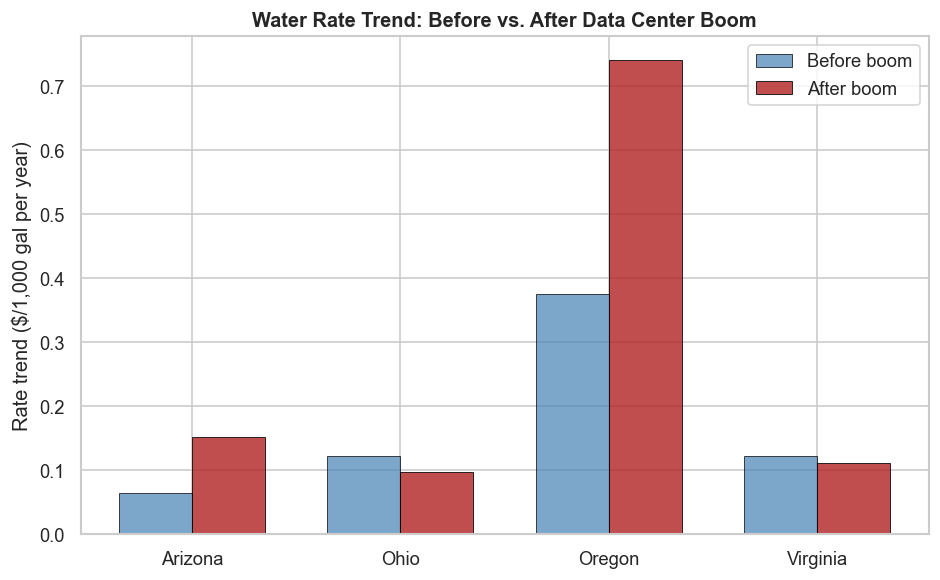

In [442]:
df_piv = df_slopes.pivot(index='state', columns='period', values='slope_per_year').reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(len(df_piv)), 0.35
ax.bar(x - w/2, df_piv.get('before', 0), w, label='Before boom',
       color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, df_piv.get('after',  0), w, label='After boom',
       color='firebrick', alpha=0.8, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_piv['state'])
ax.set_ylabel('Rate trend ($/1,000 gal per year)')
ax.set_title('Water Rate Trend: Before vs. After Data Center Boom', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig3_rate_of_increase.png', bbox_inches='tight')
plt.show()

### 2.4 Indexed price comparison

All regions indexed to 100 at their boom year. Removes starting-price differences so the *pace* of increase can be compared directly.

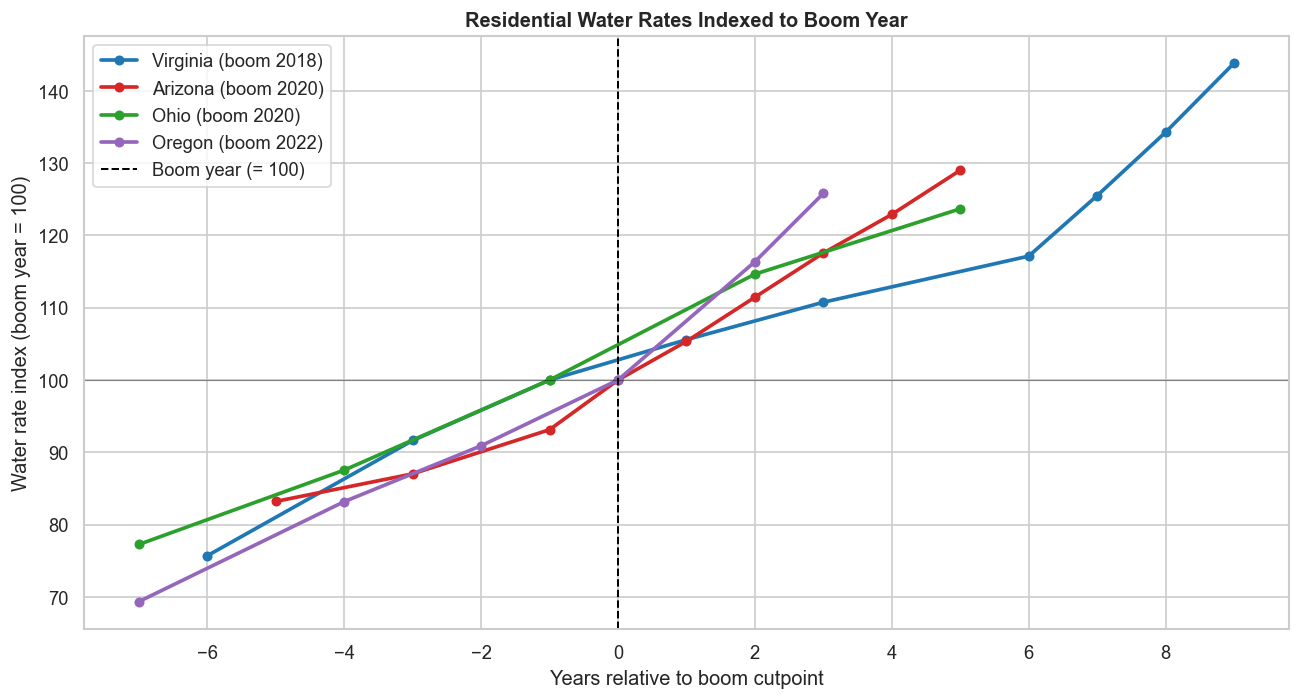

In [443]:
fig, ax = plt.subplots(figsize=(11, 6))

for abbr in ['VA', 'AZ', 'OH', 'OR']:
    boom_yr = BOOM[abbr]
    data = df_primary[df_primary['state_abbr'] == abbr].sort_values('year').copy()
    # Find the rate at or closest to boom year
    boom_row = data[data['year'] <= boom_yr]
    if boom_row.empty:
        continue
    base = boom_row.iloc[-1]['rate_per_1000gal']
    base_yr = int(boom_row.iloc[-1]['year'])
    data['indexed'] = data['rate_per_1000gal'] / base * 100
    ax.plot(data['year'] - boom_yr, data['indexed'],
            color=COLORS[abbr], linewidth=2.2, marker='o', markersize=5,
            label=f"{STATE_LABEL[abbr]} (boom {boom_yr})")

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Boom year (= 100)')
ax.axhline(100, color='black', linewidth=0.7, alpha=0.4)
ax.set_xlabel('Years relative to boom cutpoint')
ax.set_ylabel('Water rate index (boom year = 100)')
ax.set_title('Residential Water Rates Indexed to Boom Year', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig4_indexed_comparison.png', bbox_inches='tight')
plt.show()

### 2.5 All utilities — multi-series comparison

Virginia has two utilities (Loudoun + Fairfax) — both are shown to illustrate that the trend is region-wide, not utility-specific.

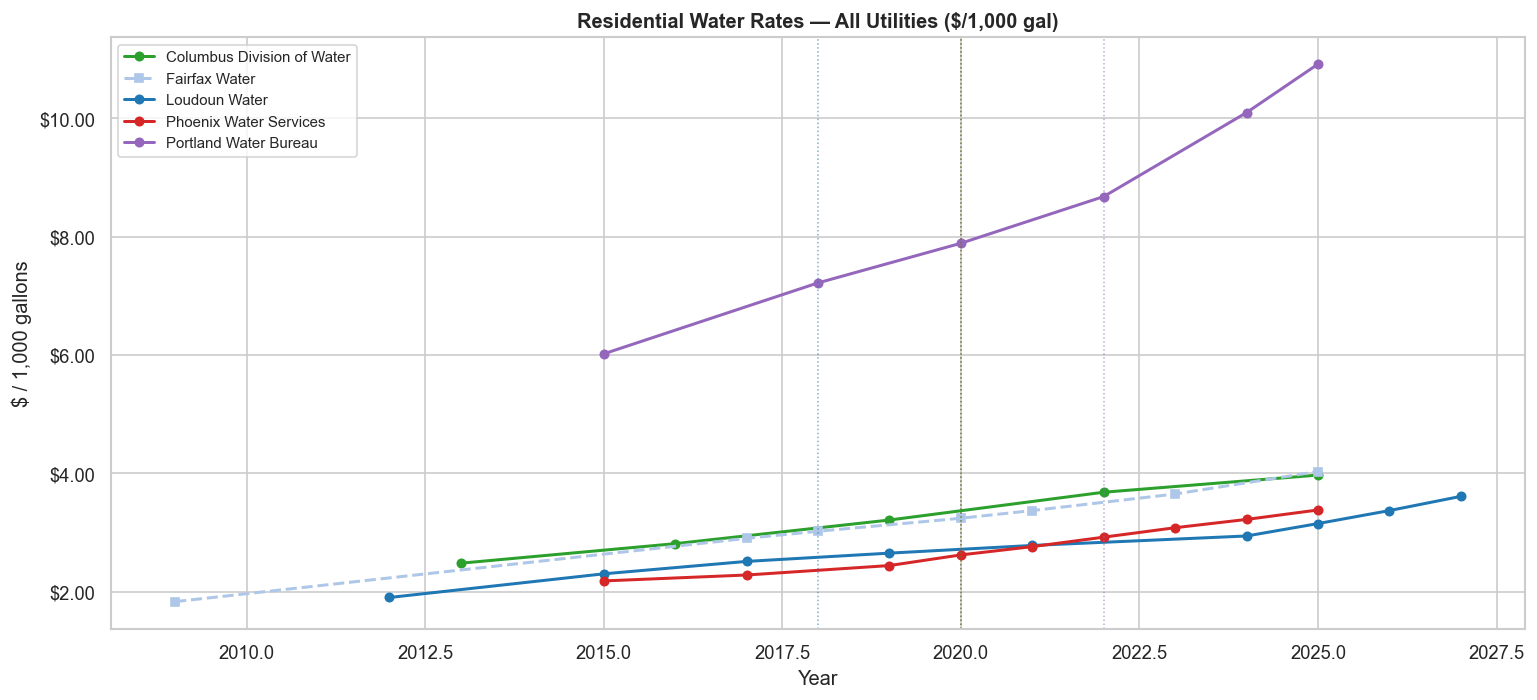

In [444]:
UTILITY_STYLE = {
    'Loudoun Water':              {'color': '#1f77b4', 'ls': '-',  'marker': 'o'},
    'Fairfax Water':              {'color': '#aec7e8', 'ls': '--', 'marker': 's'},
    'Phoenix Water Services':     {'color': '#d62728', 'ls': '-',  'marker': 'o'},
    'Columbus Division of Water': {'color': '#2ca02c', 'ls': '-',  'marker': 'o'},
    'Portland Water Bureau':      {'color': '#9467bd', 'ls': '-',  'marker': 'o'},
}

fig, ax = plt.subplots(figsize=(13, 6))

for utility, grp in df_rates.groupby('utility'):
    grp = grp.sort_values('year')
    style = UTILITY_STYLE.get(utility, {'color': 'gray', 'ls': '-', 'marker': 'x'})
    ax.plot(grp['year'], grp['rate_per_1000gal'],
            color=style['color'], linestyle=style['ls'], marker=style['marker'],
            linewidth=1.8, markersize=5, label=utility)

# Boom year shading
for abbr, boom_yr in BOOM.items():
    ax.axvline(boom_yr, color=COLORS[abbr], linestyle=':', linewidth=0.9, alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('$ / 1,000 gallons')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.set_title('Residential Water Rates — All Utilities ($/1,000 gal)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig5_all_utilities.png', bbox_inches='tight')
plt.show()

### 2.6 Summary table

In [445]:
df_summary = df_ba.copy()

# Merge slopes
for period in ['before', 'after']:
    sl = df_slopes[df_slopes['period'] == period][['state_abbr', 'slope_per_year']].rename(
        columns={'slope_per_year': f'slope_{period}'})
    df_summary = df_summary.merge(sl, on='state_abbr', how='left')

df_summary['slope_acceleration'] = (df_summary['slope_after'] - df_summary['slope_before']).round(4)

# Total observed increase (earliest to latest)
df_summary['total_pct_increase'] = (
    (df_summary['latest_rate'] - df_summary['earliest_rate'])
    / df_summary['earliest_rate'] * 100
).round(1)

df_summary.to_csv(PROC_DIR / 'summary.csv', index=False)

df_summary[['state', 'utility', 'boom_year',
            'earliest_year', 'earliest_rate',
            'latest_year', 'latest_rate',
            'total_pct_increase',
            'pct_change', 'slope_before', 'slope_after', 'slope_acceleration']].rename(columns={
    'earliest_rate':      'rate at start ($/1k gal)',
    'latest_rate':        'rate at end ($/1k gal)',
    'total_pct_increase': 'total % increase',
    'pct_change':         'before->after % chg',
    'slope_before':       'trend before ($/yr)',
    'slope_after':        'trend after ($/yr)',
    'slope_acceleration': 'acceleration ($/yr)',
})

,state,utility,boom_year,earliest_year,rate at start ($/1k gal),latest_year,rate at end ($/1k gal),total % increase,before->after % chg,trend before ($/yr),trend after ($/yr),acceleration ($/yr)
0,Virginia,Loudoun Water,2018,2012,1.90,2027,3.61,90.0,37.8,0.1229,0.1119,-0.0110
1,Arizona,Phoenix Water Services,2020,2015,2.18,2025,3.38,55.0,30.3,0.0650,0.1526,0.0876
2,Ohio,Columbus Division of Water,2020,2013,2.48,2025,3.97,60.1,35.0,0.1217,0.0967,-0.0250
3,Oregon,Portland Water Bureau,2022,2015,6.02,2025,10.92,81.4,40.6,0.3761,0.7414,0.3653


---
## Part 3 — Water Quality

Beyond cost, data center water use affects two concrete, measurable quality dimensions:

1. **Drinking water violations (EPA SDWIS)** — The Safe Drinking Water Information System tracks every health-based and monitoring/reporting violation per water system per year. Rising violation counts can signal infrastructure stress from demand surges or deferred maintenance as utilities prioritize large industrial customers.

2. **Groundwater depth (USGS NWIS)** — Data centers in Arizona and Virginia draw heavily from the regional water supply. USGS monitoring wells record depth-to-water-table, a direct measure of aquifer depletion. Arizona's Maricopa County carries a documented 4.86 million acre-foot groundwater deficit.

**APIs used (both free, no key required):**
- EPA Envirofacts SDWIS: `https://enviro.epa.gov/enviro/efservice/`
- USGS NWIS Groundwater: `https://waterservices.usgs.gov/nwis/`

### 3.1 EPA SDWIS — drinking water violations per utility

Fetches violation history for each utility from the EPA Envirofacts SDWIS database (no API key required). Violations are classified as:
- **Health-based**: MCL (maximum contaminant level) exceeded, treatment technique failure, MRDL violation
- **Monitoring/Reporting (M/R)**: required test not conducted or not reported on time

Both types matter: M/R violations can signal an underfunded or capacity-strained utility.

In [446]:
# EPA Public Water System IDs — sourced from EPA UCMR occurrence data files
PWSID = {
    'VA': ('VA6107350', 'Loudoun Water - Central System'),
    'AZ': ('AZ0407025', 'City of Phoenix'),
    'OH': ('OH2504412', 'Columbus Public Water System'),
    'OR': ('OR4100657', 'Portland Water Bureau'),
}

# EPA ECHO DFR (Detailed Facility Report) — sdwa_violations endpoint.
# Returns the current 5-year SDWIS compliance window per utility (no API key needed).
ECHO_SDWA_URL = 'https://echodata.epa.gov/echo/dfr_rest_services.get_sdwa_violations'

def fetch_violations(pwsid, label):
    try:
        r = requests.get(ECHO_SDWA_URL, params={'p_id': pwsid, 'output': 'JSON'}, timeout=30)
        r.raise_for_status()
        sources = (r.json()['Results']
                    .get('ViolationsEnforcementActions', {})
                    .get('Sources', []))
        rows = []
        for src in sources:
            rows.extend(src.get('Violations', []))
        # Drop placeholder entries (EPA returns null-filled rows when no violations)
        rows = [v for v in rows if v.get('ViolationCategoryCode') is not None]
        if not rows:
            print(f'  {label}: no violations in current 5-yr window (good!)')
            return pd.DataFrame()
        df = pd.DataFrame(rows)
        print(f'  {label} ({pwsid}): {len(df)} violations')
        return df
    except Exception as e:
        print(f'  {label}: ERROR {e}')
        return pd.DataFrame()


all_viols = []
for abbr, (pwsid, label) in PWSID.items():
    df_v = fetch_violations(pwsid, label)
    if df_v.empty:
        continue
    df_v['state_abbr'] = abbr
    df_v['utility_label'] = label
    all_viols.append(df_v)

if all_viols:
    df_viols_raw = pd.concat(all_viols, ignore_index=True)
    df_viols_raw.to_csv(RAW_DIR / 'sdwis_violations_raw.csv', index=False)
    print(f'\nTotal: {len(df_viols_raw)} violations across {df_viols_raw["state_abbr"].nunique()} states')
    print('Columns:', list(df_viols_raw.columns[:10]))
else:
    print('No violations found in 5-yr window — all utilities in compliance')
    df_viols_raw = pd.DataFrame()

  Loudoun Water - Central System (VA6107350): 1 violations
  City of Phoenix (AZ0407025): 4 violations
  Columbus Public Water System: no violations in current 5-yr window (good!)
  Portland Water Bureau (OR4100657): 2 violations

Total: 7 violations across 3 states
Columns: ['SourceID', 'CompliancePeriodBeginDate', 'CompliancePeriodEndDate', 'NonCompliancePeriodBeginDate', 'NonCompliancePeriodEndDate', 'ViolationID', 'FederalRule', 'ContaminantName', 'ViolationCategoryCode', 'ViolationCategoryDesc']


In [447]:
if df_viols_raw.empty:
    print('No violations to aggregate — skipping')
    df_vagg = pd.DataFrame()
else:
    df_v = df_viols_raw.copy()

    # ECHO columns: CompliancePeriodBeginDate, ViolationCategoryCode, ViolationCategoryDesc
    df_v['year'] = pd.to_datetime(df_v['CompliancePeriodBeginDate'], errors='coerce').dt.year

    # Health-based: MCL (maximum contaminant level), TT (treatment technique), MRDL
    # Monitoring/Reporting: MR, MON
    health_codes = {'MCL', 'TT', 'MRDL', 'PN', 'Other'}
    df_v['viol_type'] = df_v['ViolationCategoryCode'].apply(
        lambda x: 'Health-based' if str(x).strip().upper() in health_codes
                  else 'Monitoring/Reporting'
    )

    df_vagg = (
        df_v.dropna(subset=['year'])
        .astype({'year': int})
        .groupby(['state_abbr', 'utility_label', 'year', 'viol_type'])
        .size().reset_index(name='count')
    )
    df_vagg.to_csv(PROC_DIR / 'sdwis_violations_annual.csv', index=False)
    print(f'Aggregated: {len(df_vagg)} state-year-type rows')
    print(df_vagg.groupby(['state_abbr', 'viol_type'])['count'].sum().unstack(fill_value=0))

Aggregated: 6 state-year-type rows
viol_type   Health-based  Monitoring/Reporting
state_abbr                                    
AZ                     1                     3
OR                     1                     1
VA                     0                     1


### 3.2 Violations trend chart

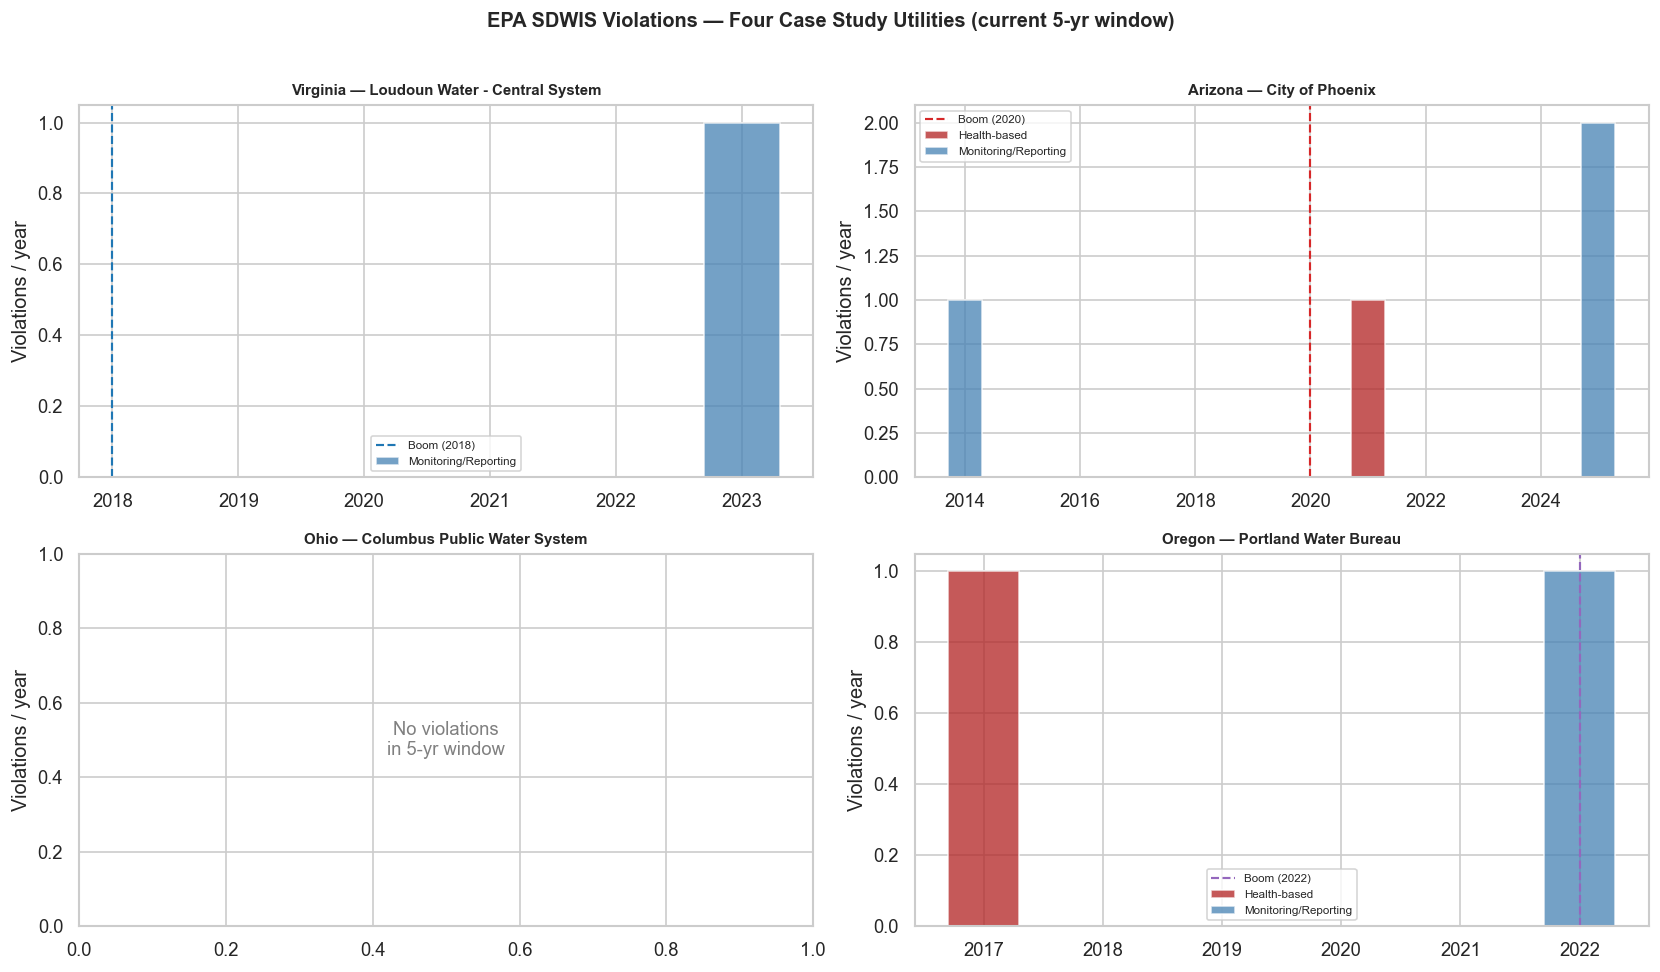

In [448]:
viol_path = PROC_DIR / 'sdwis_violations_annual.csv'
if not viol_path.exists():
    print('Run cells 3.1–3.2 first to generate violation data')
else:
    df_vagg = pd.read_csv(viol_path)
    VTYPE_COLOR = {
        'Health-based': 'firebrick',
        'Monitoring/Reporting': 'steelblue',
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
    axes = axes.flatten()

    for ax, abbr in zip(axes, ['VA', 'AZ', 'OH', 'OR']):
        sub = df_vagg[df_vagg['state_abbr'] == abbr]
        utility_label = PWSID.get(abbr, ('', 'Unknown'))[1][:30]
        ax.set_title(f"{STATE_LABEL[abbr]} — {utility_label}", fontweight='bold', fontsize=9)

        if sub.empty:
            ax.text(0.5, 0.5, 'No violations\nin 5-yr window', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='gray')
            ax.set_ylabel('Violations / year')
            continue

        for vtype, color in VTYPE_COLOR.items():
            grp = sub[sub['viol_type'] == vtype].sort_values('year')
            if grp.empty:
                continue
            ax.bar(grp['year'], grp['count'], label=vtype, color=color, alpha=0.75, width=0.6)

        ax.axvline(BOOM[abbr], color=COLORS[abbr], linestyle='--',
                   linewidth=1.3, label=f'Boom ({BOOM[abbr]})')
        ax.set_ylabel('Violations / year')
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=7)

    fig.suptitle('EPA SDWIS Violations — Four Case Study Utilities (current 5-yr window)',
                 fontsize=12, fontweight='bold', y=1.01)
    fig.tight_layout()
    fig.savefig(PROC_DIR / 'fig6_violations.png', bbox_inches='tight')
    plt.show()

### 3.3 EPA UCMR — tap water contaminant levels

The **Unregulated Contaminant Monitoring Rule (UCMR)** requires every large water utility to test for contaminants not yet regulated under the Safe Drinking Water Act. EPA publishes the full results as public ZIP/CSV files after each monitoring round:

| Round | Period | Contaminants tested |
|---|---|---|
| UCMR 3 | 2013–2015 | 30 contaminants incl. chromium-6, strontium, wastewater indicators |
| UCMR 4 | 2018–2020 | 30 contaminants incl. HAA9 disinfection byproducts, germanium |
| UCMR 5 | 2021–2023 | 29 contaminants incl. PFAS (forever chemicals), lithium |

We filter each round to our five utilities using their PWSID and measure: detection rate (% of samples above the minimum reporting level) and mean concentration. UCMR 5's PFAS results are especially relevant — data centers use PFAS-containing firefighting foam and cooling chemicals that can leach into groundwater and ultimately municipal supply.

In [449]:
import zipfile

UCMR_ROUNDS = {
    'UCMR3': {
        'url':    'https://www.epa.gov/system/files/other-files/2024-04/ucmr3-occurrence-data.zip',
        'period': '2013-2015',
    },
    'UCMR4': {
        'url':    'https://www.epa.gov/system/files/other-files/2024-04/ucmr4-occurrence-data.zip',
        'period': '2018-2020',
    },
    'UCMR5': {
        'url':    'https://www.epa.gov/system/files/other-files/2023-08/ucmr5-occurrence-data.zip',
        'period': '2021-2023',
    },
}

HEADERS = {
    'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 (KHTML, like Gecko) '
                   'Chrome/124.0.0.0 Safari/537.36'),
    'Referer': 'https://www.epa.gov/dwucmr/occurrence-data-unregulated-contaminant-monitoring-rule',
}

# UCMR files store IDs in the same 2-letter-prefix SDWIS format (e.g. 'VA6107350')
# No FIPS conversion needed — match directly against PWSID values
OUR_IDS = {abbr: pid for abbr, (pid, _) in PWSID.items()}
print('Matching UCMR records against PWS IDs:', OUR_IDS)


def download_ucmr(round_key, url):
    local_zip = RAW_DIR / f'{round_key.lower()}.zip'
    local_csv = RAW_DIR / f'{round_key.lower()}.csv'

    if local_csv.exists():
        print(f'  {round_key}: using cached CSV')
        return pd.read_csv(local_csv, dtype=str, encoding='latin-1')

    if not local_zip.exists():
        print(f'  {round_key}: downloading ...')
        r = requests.get(url, headers=HEADERS, timeout=180)
        if not r.ok:
            print(f'  {round_key}: HTTP {r.status_code} — skipping')
            return pd.DataFrame()
        local_zip.write_bytes(r.content)

    with zipfile.ZipFile(local_zip) as z:
        all_files = z.namelist()
        main_file = next((n for n in all_files if n.endswith('_All.txt')), None)
        if main_file is None:
            txt_files = [n for n in all_files if n.lower().endswith('.txt')]
            main_file = max(txt_files, key=lambda n: z.getinfo(n).file_size)
        print(f'  {round_key}: extracting {main_file}')
        with z.open(main_file) as f:
            df = pd.read_csv(f, sep='\t', dtype=str, encoding='latin-1')

    df.to_csv(local_csv, index=False)
    return df


def filter_ucmr(df, round_key):
    if df.empty:
        return pd.DataFrame()

    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

    id_col = next((c for c in df.columns if 'pwsid' in c or 'pws_id' in c), None)
    if not id_col:
        print(f'  {round_key}: no PWSID column — {list(df.columns[:8])}')
        return pd.DataFrame()

    our_ids = set(OUR_IDS.values())
    sub = df[df[id_col].str.strip().isin(our_ids)].copy()
    if sub.empty:
        print(f'  {round_key}: no match (file sample: {list(df[id_col].unique()[:3])})')
        return pd.DataFrame()

    # All UCMR rounds use: contaminant, mrl, analyticalresultvalue, analyticalresultssign
    chem_col  = next((c for c in sub.columns
                      if c == 'contaminant' or 'contaminant' in c or 'chemical' in c), None)
    # Prefer 'analyticalresultvalue' — avoid 'analyticalresultssign' (sign column, not numeric)
    result_col = next((c for c in sub.columns
                       if c in ('analyticalresultvalue', 'result', 'analyteresult', 'concentration')
                       or ('result' in c and 'value' in c)), None)
    sign_col  = next((c for c in sub.columns if 'sign' in c and 'result' in c), None)
    mrl_col   = next((c for c in sub.columns if c == 'mrl' or c.startswith('mrl')), None)
    date_col  = next((c for c in sub.columns if 'date' in c or 'collection' in c), None)

    print(f'  {round_key}: {len(sub)} rows | chem={chem_col} result={result_col} '
          f'sign={sign_col} mrl={mrl_col}')

    rename = {id_col: 'pwsid'}
    if chem_col:   rename[chem_col]   = 'contaminant'
    if result_col: rename[result_col] = 'result'
    if sign_col:   rename[sign_col]   = 'result_sign'
    if mrl_col:    rename[mrl_col]    = 'mrl'
    if date_col:   rename[date_col]   = 'sample_date'
    sub = sub.rename(columns=rename)

    sub['round']      = round_key
    sub['period']     = UCMR_ROUNDS[round_key]['period']
    id_to_abbr        = {v: k for k, v in OUR_IDS.items()}
    sub['state_abbr'] = sub['pwsid'].str.strip().map(id_to_abbr)
    return sub


ucmr_frames = []
for round_key, info in UCMR_ROUNDS.items():
    df_raw = download_ucmr(round_key, info['url'])
    df_f   = filter_ucmr(df_raw, round_key)
    if not df_f.empty:
        ucmr_frames.append(df_f)

if ucmr_frames:
    df_ucmr = pd.concat(ucmr_frames, ignore_index=True)
    df_ucmr.to_csv(RAW_DIR / 'ucmr_tap_water.csv', index=False)
    print(f'\nCombined: {len(df_ucmr)} rows')
    print(df_ucmr.groupby(['state_abbr', 'round']).size().unstack(fill_value=0))
else:
    print('\nNo UCMR data loaded')
    df_ucmr = pd.DataFrame()

Matching UCMR records against PWS IDs: {'VA': 'VA6107350', 'AZ': 'AZ0407025', 'OH': 'OH2504412', 'OR': 'OR4100657'}
  UCMR3: using cached CSV
  UCMR3: 2562 rows | chem=contaminant result=analyticalresultvalue sign=analyticalresultssign mrl=mrl
  UCMR4: using cached CSV
  UCMR4: 2281 rows | chem=contaminant result=analyticalresultvalue sign=analyticalresultssign mrl=mrl
  UCMR5: using cached CSV
  UCMR5: 2285 rows | chem=contaminant result=analyticalresultvalue sign=analyticalresultssign mrl=mrl

Combined: 7128 rows
round       UCMR3  UCMR4  UCMR5
state_abbr                     
AZ           1736   1360   1565
OH            350    323    300
OR            196    270    180
VA            280    328    240


### 3.4 UCMR detection rate and contaminant heatmap

### 3.4a PFAS before / after — contaminants tested across multiple UCMR rounds

Six PFAS compounds appear in **both** UCMR3 (2013–2015, pre-boom) and UCMR5 (2021–2023, post-boom), enabling a direct before/after comparison. These are the only contaminants where trend analysis is possible across rounds.

**Why PFAS matters for data centers:** facilities use PFAS-based aqueous film-forming foam (AFFF) for fire suppression. PFAS can leach from on-site storage into stormwater, groundwater, and ultimately municipal supply. PFOA and PFOS are the most regulated; PFBS and PFHpA have fewer limits but are flagged as emerging concerns.

PFAS detection rate (%) — UCMR3 (2013-15) vs UCMR5 (2021-23):
state_abbr contaminant  UCMR3  UCMR5  change
        AZ        PFBS    0.0   23.1    23.1
        OH        PFBS    0.0   10.0    10.0
        OH       PFHpA    0.0   10.0    10.0
        OH        PFOA    0.0   10.0    10.0


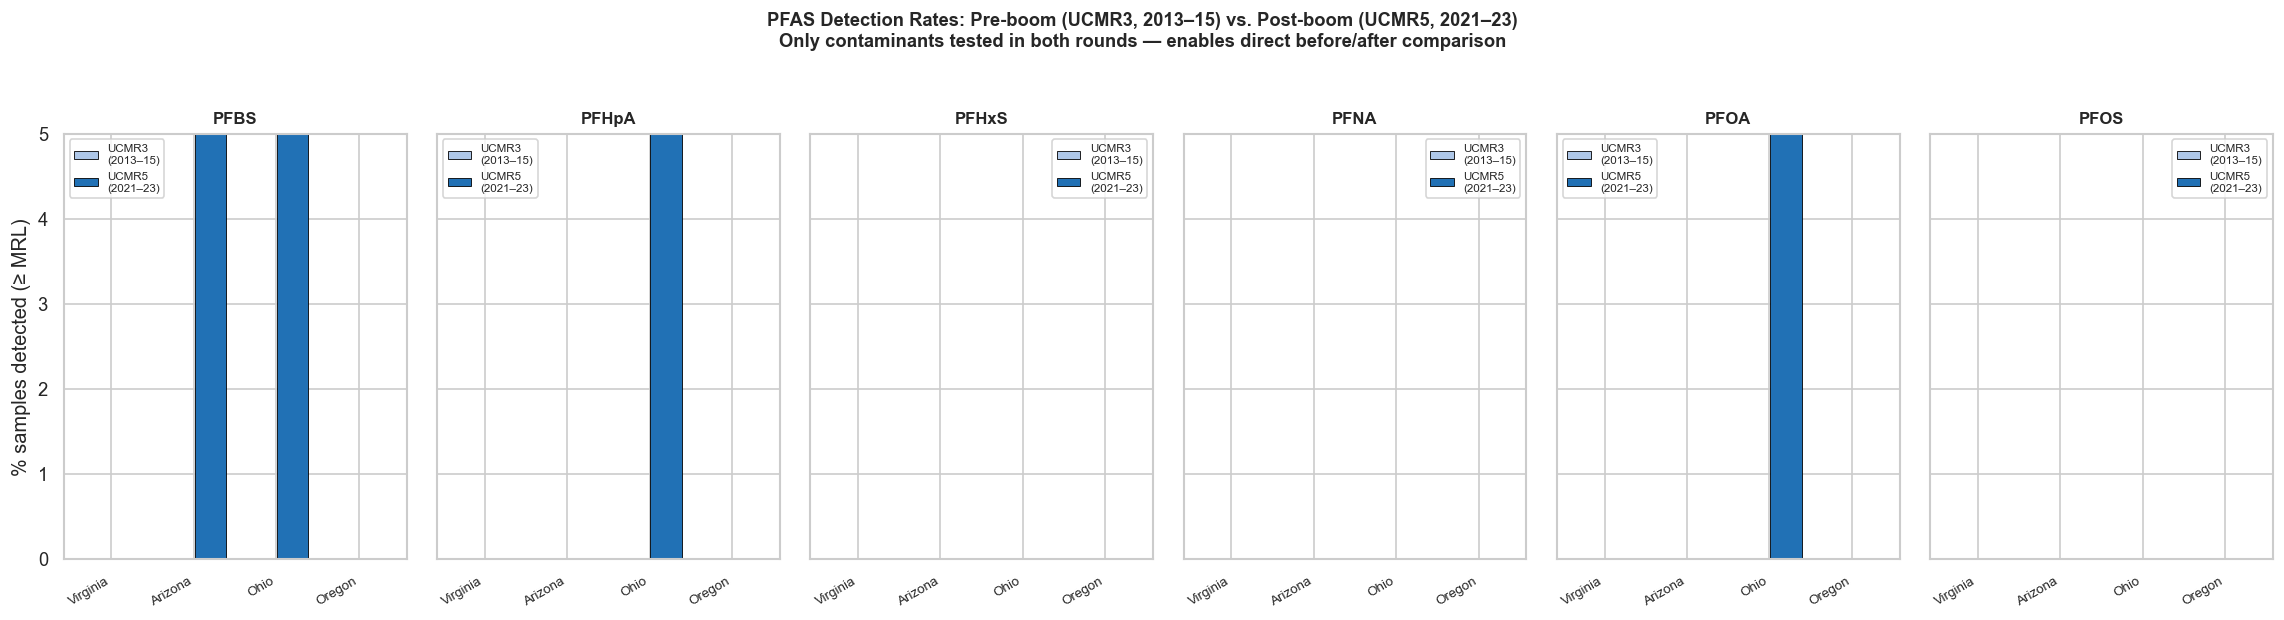

In [450]:
ucmr_path = RAW_DIR / 'ucmr_tap_water.csv'
if not ucmr_path.exists():
    print('Run cell 3.3 first')
else:
    df_ucmr = pd.read_csv(ucmr_path, dtype=str)
    if 'result_sign' in df_ucmr.columns:
        df_ucmr['detected'] = df_ucmr['result_sign'].str.strip().ne('<')
    else:
        df_ucmr['detected'] = True

    PFAS_6 = ['PFBS', 'PFHpA', 'PFHxS', 'PFNA', 'PFOA', 'PFOS']
    STATE_ORDER = ['VA', 'AZ', 'OH', 'OR']

    sub = df_ucmr[df_ucmr['contaminant'].isin(PFAS_6) &
                  df_ucmr['round'].isin(['UCMR3', 'UCMR5'])].copy()

    det = (sub.groupby(['state_abbr', 'round', 'contaminant'])['detected']
              .agg(detected='sum', total='count').reset_index())
    det['pct'] = (det['detected'] / det['total'] * 100).round(1)

    # Pivot to UCMR3 vs UCMR5 columns per state × compound
    piv = det.pivot_table(index=['state_abbr', 'contaminant'],
                          columns='round', values='pct').reindex(
                          columns=['UCMR3', 'UCMR5']).fillna(0).reset_index()
    piv['change'] = (piv['UCMR5'] - piv['UCMR3']).round(1)

    print('PFAS detection rate (%) — UCMR3 (2013-15) vs UCMR5 (2021-23):')
    print(piv[piv['change'] != 0].to_string(index=False))

    # --- Grouped bar chart: UCMR3 vs UCMR5 per state, one group per compound ---
    compounds_detected = piv[piv[['UCMR3','UCMR5']].sum(axis=1) > 0]['contaminant'].unique()

    if len(compounds_detected) == 0:
        print('No PFAS detections in either round for any region')
    else:
        # Show all 6 compounds even if some are zero — makes absence visible
        fig, axes = plt.subplots(1, len(PFAS_6),
                                 figsize=(3.2 * len(PFAS_6), 5),
                                 sharey=True)

        for ax, compound in zip(axes, PFAS_6):
            cpiv = piv[piv['contaminant'] == compound].set_index('state_abbr')
            x = np.arange(len(STATE_ORDER))
            u3 = [cpiv.loc[s, 'UCMR3'] if s in cpiv.index else 0 for s in STATE_ORDER]
            u5 = [cpiv.loc[s, 'UCMR5'] if s in cpiv.index else 0 for s in STATE_ORDER]

            ax.bar(x - 0.2, u3, 0.38, label='UCMR3\n(2013–15)', color='#aec7e8',
                   edgecolor='black', linewidth=0.5)
            ax.bar(x + 0.2, u5, 0.38, label='UCMR5\n(2021–23)', color='#2171b5',
                   edgecolor='black', linewidth=0.5)

            ax.set_title(compound, fontweight='bold', fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels([STATE_LABEL[s] for s in STATE_ORDER],
                               rotation=30, ha='right', fontsize=8)
            ax.set_ylim(0, max(max(u3 + u5) * 1.3, 5))
            if ax == axes[0]:
                ax.set_ylabel('% samples detected (≥ MRL)')
            ax.legend(fontsize=7)

        fig.suptitle('PFAS Detection Rates: Pre-boom (UCMR3, 2013–15) vs. Post-boom (UCMR5, 2021–23)\n'
                     'Only contaminants tested in both rounds — enables direct before/after comparison',
                     fontweight='bold', fontsize=11, y=1.03)
        fig.tight_layout()
        fig.savefig(PROC_DIR / 'fig8_pfas_before_after.png', bbox_inches='tight')
        plt.show()

Detection rates:
round       UCMR3  UCMR4  UCMR5
state_abbr                     
AZ           25.1   22.9    4.5
OH           28.6   44.9    4.3
OR           19.4   55.6    0.0
VA           19.3   45.1    0.4


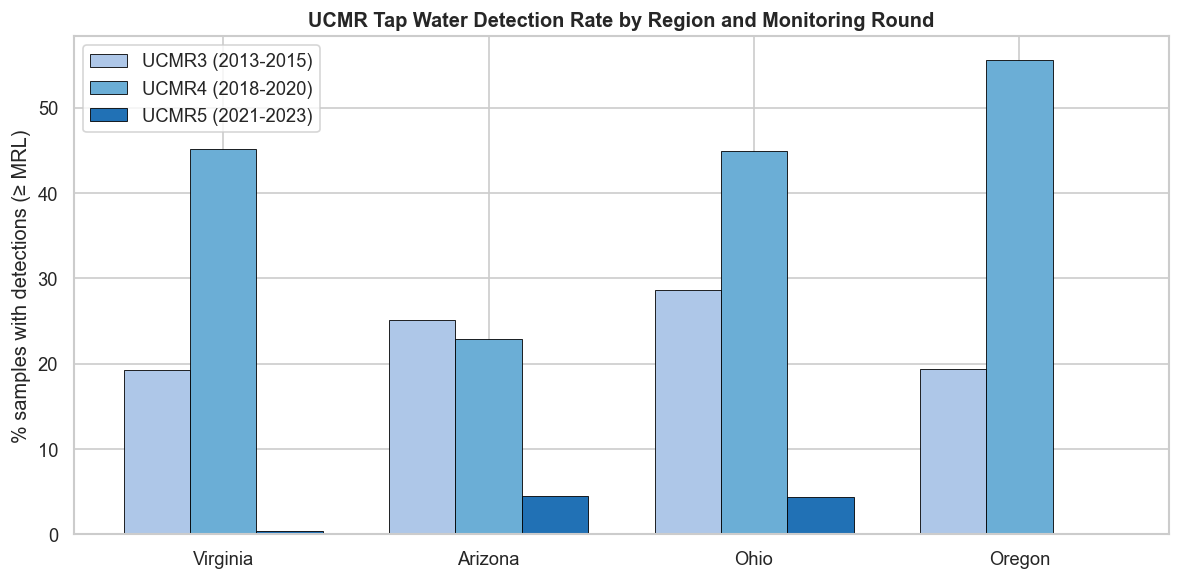

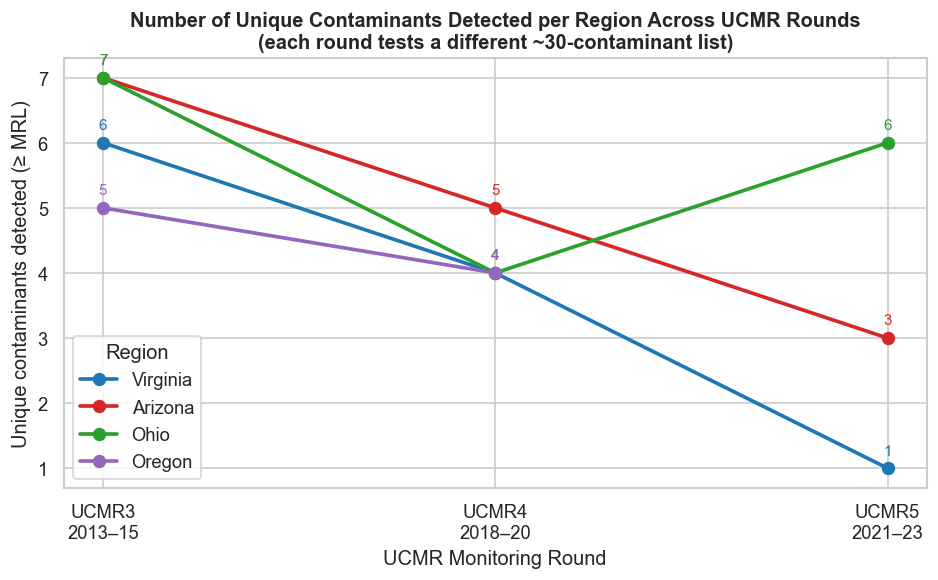

In [451]:
ucmr_path = RAW_DIR / 'ucmr_tap_water.csv'
if not ucmr_path.exists():
    print('Run cell 3.3 first to load UCMR data')
else:
    df_ucmr = pd.read_csv(ucmr_path, dtype=str)

    # Determine detection: sign='<' means below MRL (not detected); '=' means detected.
    if 'result_sign' in df_ucmr.columns:
        df_ucmr['detected'] = df_ucmr['result_sign'].str.strip().ne('<')
    elif 'result' in df_ucmr.columns and 'mrl' in df_ucmr.columns:
        df_ucmr['result_num'] = pd.to_numeric(df_ucmr['result'], errors='coerce')
        df_ucmr['mrl_num']    = pd.to_numeric(df_ucmr['mrl'],    errors='coerce')
        df_ucmr['detected']   = df_ucmr['result_num'] >= df_ucmr['mrl_num'].fillna(0)
    else:
        df_ucmr['detected'] = True

    # --- Detection rate bar chart ---
    det_rate = (
        df_ucmr.groupby(['state_abbr', 'round'])['detected']
        .agg(detections='sum', total='count')
        .reset_index()
    )
    det_rate['pct_detected'] = (det_rate['detections'] / det_rate['total'] * 100).round(1)
    det_rate.to_csv(PROC_DIR / 'ucmr_detection_rates.csv', index=False)
    print('Detection rates:')
    print(det_rate.pivot(index='state_abbr', columns='round', values='pct_detected').round(1))

    rounds = sorted(det_rate['round'].unique())
    states = ['VA', 'AZ', 'OH', 'OR']
    ROUND_COLORS = {'UCMR3': '#aec7e8', 'UCMR4': '#6baed6', 'UCMR5': '#2171b5'}

    fig, ax = plt.subplots(figsize=(10, 5))
    x, width = np.arange(len(states)), 0.25
    for i, rnd in enumerate(rounds):
        sub  = det_rate[det_rate['round'] == rnd].set_index('state_abbr')
        vals = [sub.loc[s, 'pct_detected'] if s in sub.index else 0 for s in states]
        ax.bar(x + (i - 1) * width, vals, width,
               label=f'{rnd} ({UCMR_ROUNDS[rnd]["period"]})',
               color=ROUND_COLORS.get(rnd, 'gray'), edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([STATE_LABEL[s] for s in states])
    ax.set_ylabel('% samples with detections (≥ MRL)')
    ax.set_title('UCMR Tap Water Detection Rate by Region and Monitoring Round', fontweight='bold')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PROC_DIR / 'fig6_ucmr_detection_rate.png', bbox_inches='tight')
    plt.show()

    # --- Line chart: unique contaminants detected per region over UCMR rounds ---
    # Each round tests a rotating list of ~30 contaminants.  Counting how many unique
    # contaminants each region detected (above MRL) shows whether contamination breadth
    # has changed over time — even though the contaminant lists differ across rounds.
    if 'contaminant' in df_ucmr.columns:
        STATE_ORDER = ['VA', 'AZ', 'OH', 'OR']
        ROUND_LABELS = {
            'UCMR3': 'UCMR3\n2013–15',
            'UCMR4': 'UCMR4\n2018–20',
            'UCMR5': 'UCMR5\n2021–23',
        }

        # Count unique contaminants detected (above MRL) per state per round
        unique_det = (
            df_ucmr[df_ucmr['detected']]
            .groupby(['state_abbr', 'round'])['contaminant']
            .nunique()
            .reset_index(name='n_contaminants')
        )

        fig, ax = plt.subplots(figsize=(8, 5))
        for abbr in STATE_ORDER:
            sub = unique_det[unique_det['state_abbr'] == abbr].sort_values('round')
            xs  = [ROUND_LABELS.get(r, r) for r in sub['round']]
            ys  = sub['n_contaminants'].tolist()
            ax.plot(xs, ys, color=COLORS[abbr], linewidth=2.2,
                    marker='o', markersize=7, label=STATE_LABEL[abbr])
            for xi, yi in zip(xs, ys):
                ax.annotate(str(yi), xy=(xi, yi),
                            xytext=(0, 8), textcoords='offset points',
                            ha='center', fontsize=9, color=COLORS[abbr])

        ax.set_xlabel('UCMR Monitoring Round')
        ax.set_ylabel('Unique contaminants detected (≥ MRL)')
        ax.set_title(
            'Number of Unique Contaminants Detected per Region Across UCMR Rounds\n'
            '(each round tests a different ~30-contaminant list)',
            fontweight='bold')
        ax.legend(title='Region')
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        fig.tight_layout()
        fig.savefig(PROC_DIR / 'fig7_ucmr_contaminant_graph.png', bbox_inches='tight')
        plt.show()


### 3.5 Water quality summary table

Combines rate change, SDWIS violations, and groundwater depth into one cross-region summary.

In [452]:
rows = []
for abbr in ['VA', 'AZ', 'OH', 'OR']:
    boom_yr = BOOM[abbr]
    row = {'State': STATE_LABEL[abbr], 'Boom year': boom_yr,
           'Primary utility': PRIMARY_UTILITY[abbr]}

    # Rate change from Part 2 summary
    if not df_ba.empty:
        ba = df_ba[df_ba['state_abbr'] == abbr]
        if not ba.empty:
            row['Rate pct change (before->after)'] = f"+{ba.iloc[0]['pct_change']}%"
            row['Latest rate ($/1k gal)'] = f"${ba.iloc[0]['latest_rate']:.2f}"

    # SDWIS violations post-boom
    viol_path = PROC_DIR / 'sdwis_violations_annual.csv'
    if viol_path.exists():
        dv = pd.read_csv(viol_path)
        sub = dv[(dv['state_abbr'] == abbr) & (dv['year'] >= boom_yr)]
        hb = sub[sub['viol_type'] == 'Health-based']['count'].sum()
        mr = sub[sub['viol_type'] == 'Monitoring/Reporting']['count'].sum()
        row['Health-based violations (post-boom)'] = int(hb) if hb else 0
        row['M/R violations (post-boom)'] = int(mr) if mr else 0
    else:
        row['Health-based violations (post-boom)'] = 'not loaded'
        row['M/R violations (post-boom)'] = 'not loaded'

    # UCMR detection rate — UCMR5 (most recent, includes PFAS)
    det_path = PROC_DIR / 'ucmr_detection_rates.csv'
    if det_path.exists():
        dd = pd.read_csv(det_path)
        sub = dd[(dd['state_abbr'] == abbr) & (dd['round'] == 'UCMR5')]
        row['UCMR5 detection rate (%)'] = (f"{sub.iloc[0]['pct_detected']}%"
                                            if not sub.empty else 'n/a')
    else:
        row['UCMR5 detection rate (%)'] = 'not loaded'

    rows.append(row)

df_qual_summary = pd.DataFrame(rows)
df_qual_summary.to_csv(PROC_DIR / 'water_quality_summary.csv', index=False)
df_qual_summary

,State,Boom year,Primary utility,Rate pct change (before->after),Latest rate ($/1k gal),Health-based violations (post-boom),M/R violations (post-boom),UCMR5 detection rate (%)
0,Virginia,2018,Loudoun Water,+37.8%,$3.61,0,1,0.4%
1,Arizona,2020,Phoenix Water Services,+30.3%,$3.38,1,2,4.5%
2,Ohio,2020,Columbus Division of Water,+35.0%,$3.97,0,0,4.3%
3,Oregon,2022,Portland Water Bureau,+40.6%,$10.92,0,1,0.0%


---
## Notes on data limitations

**Rates (Parts 1–2):**
- No national water rate API — rates curated manually from primary utility PDFs and city ordinances.
- All values converted to $/1,000 gal (1 CCF = 748 gal). Only Tier 1 volumetric rates used for comparability.
- Rate increases have multiple drivers; correlations should be read alongside the qualitative regulatory record in the README.

**SDWIS violations (Section 3.1–3.2):**
- PWS IDs may need verification at EPA's SDWIS public search. Zero violations is genuinely possible for large, well-funded municipal utilities.
- Violations data carries a 6–12 month reporting lag; 2024–2025 counts may be incomplete.

**UCMR tap water data (Section 3.3–3.4):**
- UCMR monitors a rotating list of ~30 unregulated contaminants per round. A contaminant not appearing does not mean it is absent — it may simply not have been on that round's list.
- PFAS detection in UCMR 5 (2021–2023) is particularly relevant to data centers: facilities use PFAS-based aqueous film-forming foam (AFFF) for fire suppression, which can leach into municipal supply.
- Detection above the MRL is not the same as exceeding a health limit — many detected contaminants have no regulatory limit yet. The EWG Tap Water Database (ewg.org/tapwater) provides utility-level context against health guidelines.
- **Causality caveat**: UCMR detections reflect regional contamination sources broadly. Attributing specific detections to data centers requires additional site-specific evidence.

In [453]:
import shutil
from pathlib import Path

VIZ_DIR = Path('../visualizations')
VIZ_DIR.mkdir(exist_ok=True)

prefix = 'water'
for png in sorted(PROC_DIR.glob('*.png')):
    dest = VIZ_DIR / f'water_{png.name}'
    shutil.copy2(png, dest)
    print(f'  → {dest.name}')
print(f'Exported {len(list(PROC_DIR.glob("*.png")))} figures to visualizations/')

  → water_fig1_water_rate_trends.png
  → water_fig2_before_after.png
  → water_fig3_rate_of_increase.png
  → water_fig4_indexed_comparison.png
  → water_fig5_all_utilities.png
  → water_fig6_ucmr_detection_rate.png
  → water_fig6_violations.png
  → water_fig7_groundwater_depth.png
  → water_fig7_ucmr_contaminant_graph.png
  → water_fig7_ucmr_contaminant_heatmap.png
  → water_fig8_pfas_before_after.png
Exported 11 figures to visualizations/
